# 09 - Explicabilidad del Modelo con SHAP
## Etapa de Interpretabilidad: ¿Por qué el modelo predice lo que predice?

**Objetivo:** Usar SHAP (SHapley Additive exPlanations) para entender las decisiones  
del modelo tanto a nivel global (qué features importan) como individual  
(por qué este modelo predijo X para esta vivienda concreta).

**¿Por qué es crítico en producción?**  
- Sectores regulados (banca, salud, seguros) exigen justificar decisiones automáticas  
- Detectar sesgos del modelo antes de que lleguen a producción  
- Generar confianza en el equipo de negocio y en los usuarios finales  
- Depurar errores: entender por qué el modelo falla en ciertos casos

**¿Qué es SHAP?**  
Basado en la teoría de juegos de Shapley: cada feature recibe un valor que representa  
su contribución **marginal** a la predicción, promediado sobre todas las posibles  
combinaciones de features. Es el método más robusto y matematicamente fundamentado.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import shap
from sklearn.metrics import mean_squared_error, r2_score
from pathlib import Path

# ── ROOT dinámico ──────────────────────────────────────────────────────────
ROOT = Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

DATA_DIR = ROOT / 'data' / 'processed'
EXP_DIR  = ROOT / 'experiments'

print(f'ROOT   : {ROOT}')
print(f'SHAP   : {shap.__version__}')

# Inicializar JS para visualizaciones interactivas (opcional en Jupyter)
shap.initjs()

ROOT   : C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida
SHAP   : 0.45.1


## 1. Cargar Modelo y Datos

In [2]:
# ── Cargar modelo y datos ─────────────────────────────────────────────────
modelo  = joblib.load(EXP_DIR / 'modelo_produccion.pkl')
scaler  = joblib.load(EXP_DIR / 'scaler.pkl')

train = pd.read_csv(DATA_DIR / 'train.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')

TARGET  = 'MedHouseVal'
X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]
X_test  = test.drop(columns=[TARGET])
y_test  = test[TARGET]

# Verificar que el modelo funciona
y_pred = modelo.predict(X_test)
rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
r2     = r2_score(y_test, y_pred)
print(f'Modelo cargado : {type(modelo).__name__}')
print(f'RMSE test      : {rmse:.4f}')
print(f'R² test        : {r2:.4f}')
print(f'Features ({X_train.shape[1]}): {list(X_train.columns)}')

Modelo cargado : GradientBoostingRegressor
RMSE test      : 0.4225
R² test        : 0.8638
Features (13): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'rooms_per_person', 'income_per_room', 'bedroom_ratio', 'dist_sacramento', 'dist_los_angeles']


## 2. Calcular los Valores SHAP

El `TreeExplainer` de SHAP está optimizado para modelos basados en árboles  
(Random Forest, Gradient Boosting, XGBoost). Es mucho más rápido que el  
`KernelExplainer` genérico y produce los mismos resultados.

Para cada muestra y cada feature, SHAP calcula un valor que indica:  
- **Positivo**: esa feature empuja la predicción hacia arriba (precio más alto)  
- **Negativo**: esa feature empuja la predicción hacia abajo (precio más bajo)  
- **Cero**: esa feature no afecta a esta predicción concreta

In [3]:
# ── Crear el explainer ───────────────────────────────────────────────────
# TreeExplainer: optimizado para modelos de árboles
explainer = shap.TreeExplainer(modelo)

# Calcular SHAP values para el test set
# shap_values tiene forma (n_muestras, n_features)
print('Calculando SHAP values para el test set...')
shap_values = explainer.shap_values(X_test)

print(f'Shape SHAP values : {shap_values.shape}')
print(f'Shape X_test      : {X_test.shape}')
ev = float((float(explainer.expected_value) if hasattr(explainer.expected_value, '__len__') else explainer.expected_value)) if hasattr((float(explainer.expected_value) if hasattr(explainer.expected_value, '__len__') else explainer.expected_value), '__len__') else (float(explainer.expected_value) if hasattr(explainer.expected_value, '__len__') else explainer.expected_value)
print(f'Expected value    : {ev:.4f}')
print(f'  (prediccion base si no sabemos nada de la vivienda)')
print(f'  (predicción base si no sabemos nada de la vivienda)')

# Vista rápida: contribución promedio por feature
shap_df = pd.DataFrame({
    'feature'          : X_test.columns,
    'shap_mean_abs'    : np.abs(shap_values).mean(axis=0),
    'shap_mean_signed' : shap_values.mean(axis=0),
}).sort_values('shap_mean_abs', ascending=False)

print()
print(shap_df.to_string(index=False))

Calculando SHAP values para el test set...


Shape SHAP values : (4128, 13)
Shape X_test      : (4128, 13)
Expected value    : 2.0720
  (prediccion base si no sabemos nada de la vivienda)
  (predicción base si no sabemos nada de la vivienda)

         feature  shap_mean_abs  shap_mean_signed
       Longitude       0.298296          0.004977
        Latitude       0.296721         -0.018828
          MedInc       0.182011         -0.018980
 income_per_room       0.174840         -0.006564
rooms_per_person       0.161088         -0.013856
dist_los_angeles       0.145908         -0.009417
 dist_sacramento       0.100290          0.036489
   bedroom_ratio       0.089733          0.005246
        AveOccup       0.078102          0.003398
        AveRooms       0.049252         -0.004943
        HouseAge       0.042205          0.001322
      Population       0.022059          0.001116
       AveBedrms       0.016786          0.004001


## 3. Importancia Global — ¿Qué Features Importan Más?

El **beeswarm plot** (o summary plot) muestra la distribución completa de los  
valores SHAP para todas las muestras y features a la vez:
- Eje X: valor SHAP (impacto en la predicción)
- Color: valor real de la feature (rojo = alto, azul = bajo)
- Cada punto es una vivienda del test set

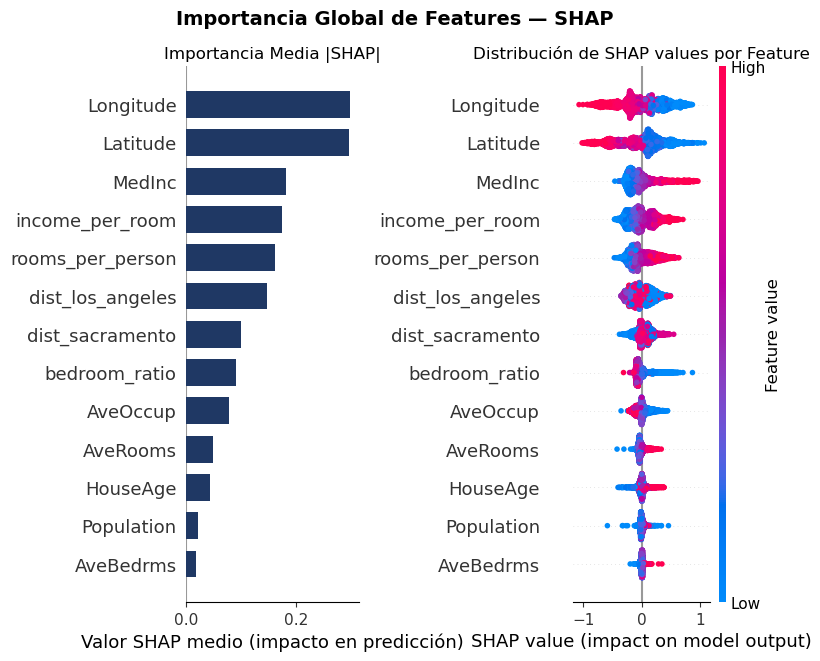

Lectura del beeswarm plot:
  - Cada punto = una vivienda del test set
  - Posición X = contribución de esa feature a la predicción
  - Color      = valor real de la feature (rojo=alto, azul=bajo)
  - MedInc rojo a la derecha → ingreso alto sube el precio
  - MedInc azul a la izquierda → ingreso bajo baja el precio


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Importancia Global de Features — SHAP', fontsize=14, fontweight='bold')

# ── Plot 1: Bar plot (importancia media) ─────────────────────────────────
plt.sca(axes[0])
shap.summary_plot(shap_values, X_test, plot_type='bar',
                  show=False, color='#1F3864')
axes[0].set_title('Importancia Media |SHAP|', fontsize=12)
axes[0].set_xlabel('Valor SHAP medio (impacto en predicción)')

# ── Plot 2: Beeswarm plot (distribución completa) ─────────────────────────
plt.sca(axes[1])
shap.summary_plot(shap_values, X_test, show=False)
axes[1].set_title('Distribución de SHAP values por Feature', fontsize=12)

plt.tight_layout()
plt.show()

print('Lectura del beeswarm plot:')
print('  - Cada punto = una vivienda del test set')
print('  - Posición X = contribución de esa feature a la predicción')
print('  - Color      = valor real de la feature (rojo=alto, azul=bajo)')
print('  - MedInc rojo a la derecha → ingreso alto sube el precio')
print('  - MedInc azul a la izquierda → ingreso bajo baja el precio')

## 4. Dependence Plots — Relación entre Feature y SHAP

El **dependence plot** muestra cómo varía el valor SHAP de una feature  
en función de su valor real. Revela relaciones no lineales que el modelo  
ha aprendido, imposibles de ver con feature importance clásica.

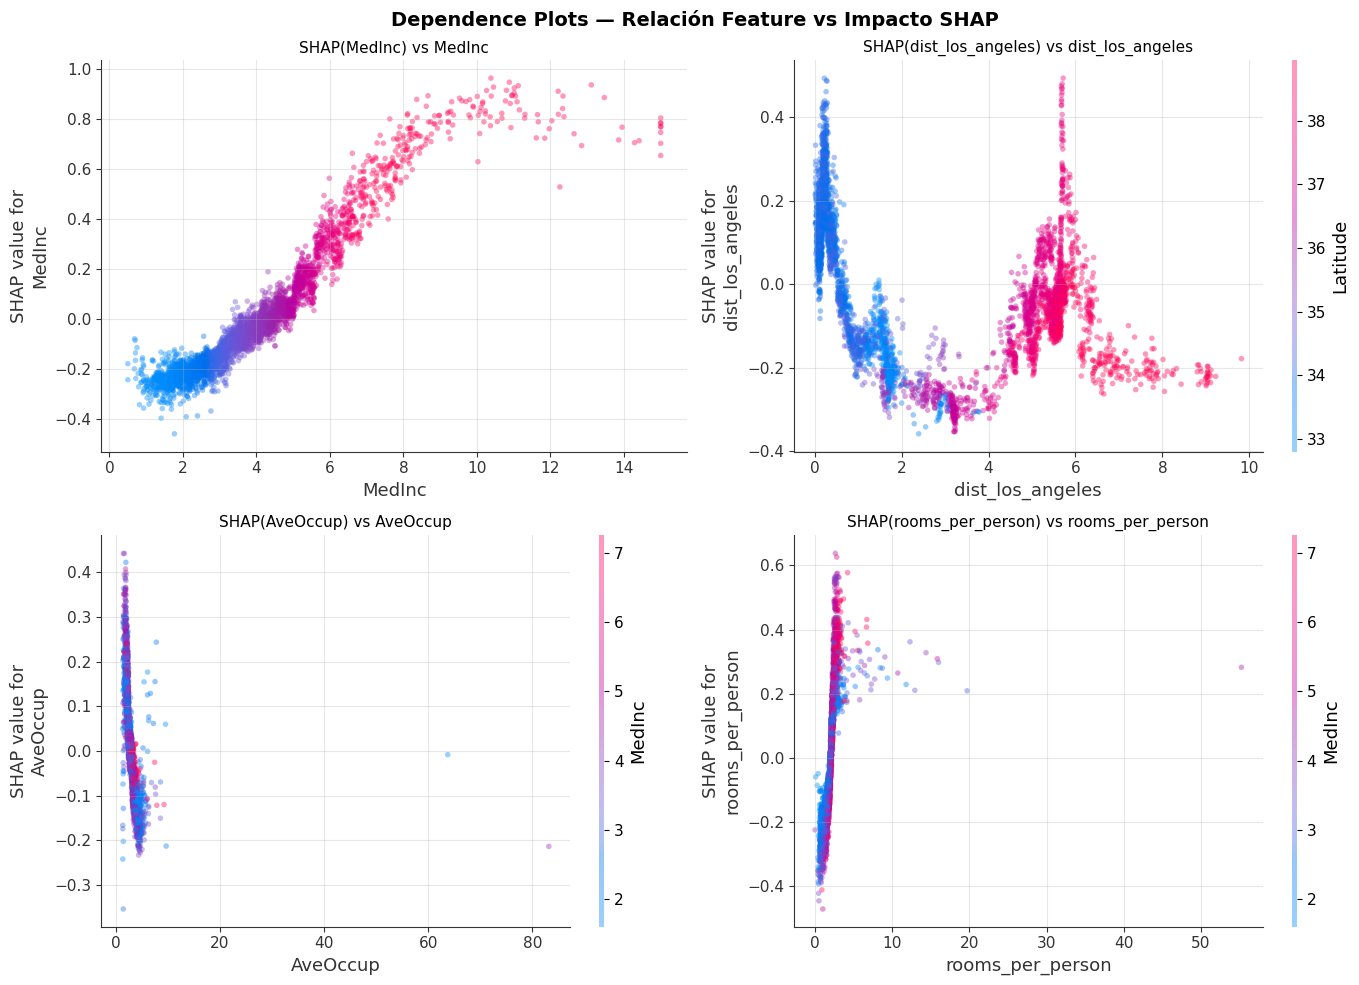

Qué revelan los dependence plots:
  MedInc     : relación positiva no lineal — umbrales de rendimiento
  dist_LA    : viviendas cerca de LA tienen mayor impacto negativo
  AveOccup   : alta ocupación deprime el precio drásticamente
  rooms/person: más espacio por persona → precio más alto (hasta cierto punto)


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dependence Plots — Relación Feature vs Impacto SHAP',
             fontsize=14, fontweight='bold')

features_dep = ['MedInc', 'dist_los_angeles', 'AveOccup', 'rooms_per_person']
colores_dep  = ['MedInc', 'Latitude', 'MedInc', 'MedInc']

for i, (feat, color_feat) in enumerate(zip(features_dep, colores_dep)):
    ax = axes[i // 2][i % 2]
    plt.sca(ax)
    shap.dependence_plot(
        feat, shap_values, X_test,
        interaction_index=color_feat,
        ax=ax, show=False, alpha=0.4
    )
    ax.set_title(f'SHAP({feat}) vs {feat}', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Qué revelan los dependence plots:')
print('  MedInc     : relación positiva no lineal — umbrales de rendimiento')
print('  dist_LA    : viviendas cerca de LA tienen mayor impacto negativo')
print('  AveOccup   : alta ocupación deprime el precio drásticamente')
print('  rooms/person: más espacio por persona → precio más alto (hasta cierto punto)')

## 5. Explicabilidad Individual — ¿Por qué Esta Predicción Concreta?

El **waterfall plot** y el **force plot** muestran cómo cada feature contribuye  
a la predicción de **una vivienda específica**. Esto es lo que se necesita para  
justificar una decisión automatizada ante un cliente o regulador.

Analizaremos dos casos contrastados:
- Una vivienda cara (San Francisco, MedInc alto)
- Una vivienda barata (zona rural, MedInc bajo)

In [6]:
# Seleccionar dos casos representativos
idx_caro   = y_test.nlargest(5).index[2]
idx_barato = y_test.nsmallest(5).index[2]

casos = [
    (idx_caro,   'Vivienda cara (zona de alto ingreso)',   '#1F3864'),
    (idx_barato, 'Vivienda barata (zona rural)',           '#C0392B'),
]

sep = '=' * 55
ev  = float(explainer.expected_value) if hasattr(explainer.expected_value, '__len__') else explainer.expected_value

for idx, titulo, color in casos:
    pos = X_test.index.get_loc(idx)

    pred_real = y_test.loc[idx]
    pred_mod  = modelo.predict(X_test.loc[[idx]])[0]

    base_usd  = ev * 100_000
    real_usd  = pred_real * 100_000
    pred_usd  = pred_mod  * 100_000
    err_usd   = abs(pred_real - pred_mod) * 100_000

    print()
    print(sep)
    print(titulo)
    print(sep)
    print('  Precio real      : $' + f'{real_usd:,.0f}')
    print('  Precio predicho  : $' + f'{pred_usd:,.0f}')
    print('  Error            : $' + f'{err_usd:,.0f}')
    print('  Valor base       : $' + f'{base_usd:,.0f}')
    print()
    print('  Contribucion por feature (SHAP):')
    contribs = list(zip(X_test.columns, shap_values[pos]))
    contribs_sorted = sorted(contribs, key=lambda x: abs(x[1]), reverse=True)
    for feat, sv in contribs_sorted[:6]:
        sign  = '+' if sv > 0 else '-'
        usd   = abs(sv) * 100_000
        print(f'    {feat:25s}: {sign}$' + f'{usd:,.0f}')



Vivienda cara (zona de alto ingreso)
  Precio real      : $500,001
  Precio predicho  : $402,192
  Error            : $97,809
  Valor base       : $207,203

  Contribucion por feature (SHAP):
    Latitude                 : +$53,102
    income_per_room          : +$41,352
    AveOccup                 : +$35,562
    dist_los_angeles         : +$27,304
    rooms_per_person         : +$19,397
    HouseAge                 : +$13,888

Vivienda barata (zona rural)
  Precio real      : $22,500
  Precio predicho  : $97,413
  Error            : $74,913
  Valor base       : $207,203

  Contribucion por feature (SHAP):
    Latitude                 : -$50,200
    MedInc                   : -$27,249
    bedroom_ratio            : +$25,005
    dist_los_angeles         : -$21,853
    dist_sacramento          : -$21,128
    Longitude                : +$12,780


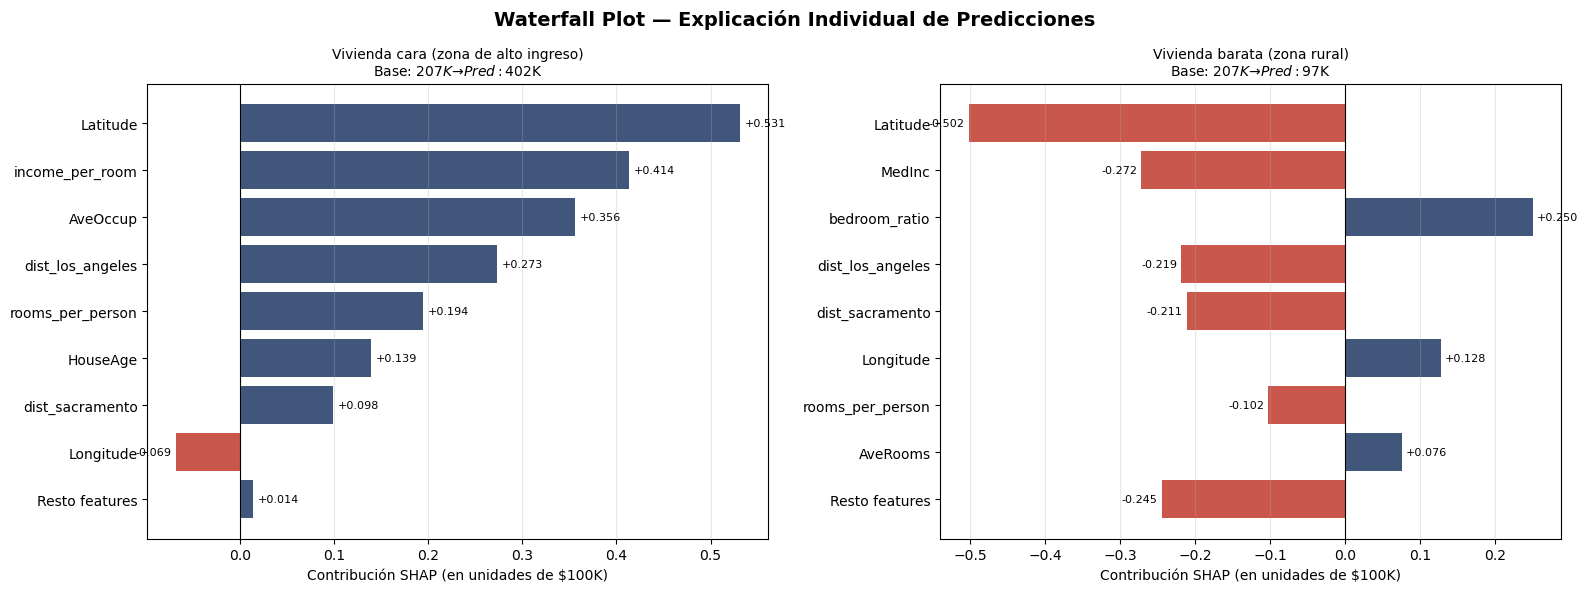

In [7]:
# ── Waterfall plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Waterfall Plot — Explicación Individual de Predicciones',
             fontsize=14, fontweight='bold')

for i, (idx, titulo, _) in enumerate(casos):
    pos = X_test.index.get_loc(idx)
    ax  = axes[i]

    # Construir el waterfall manualmente para mayor control visual
    sv       = shap_values[pos]
    feats    = list(X_test.columns)
    ev_raw   = explainer.expected_value
    base     = float(ev_raw) if hasattr(ev_raw, '__len__') else ev_raw
    pred     = base + sv.sum()

    # Top 8 features por impacto absoluto
    idx_top  = np.argsort(np.abs(sv))[::-1][:8]
    sv_top   = sv[idx_top]
    ft_top   = [feats[j] for j in idx_top]
    resto    = sv.sum() - sv_top.sum()

    labels   = ft_top + ['Resto features']
    values   = list(sv_top) + [resto]
    colors   = ['#1F3864' if v > 0 else '#C0392B' for v in values]

    bars = ax.barh(labels[::-1], values[::-1], color=colors[::-1], alpha=0.85)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_xlabel('Contribución SHAP (en unidades de $100K)')
    ax.set_title(f'{titulo}\nBase: ${base*100:.0f}K → Pred: ${pred*100:.0f}K',
                 fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    for bar, val in zip(bars, values[::-1]):
        ax.text(val + (0.005 if val >= 0 else -0.005),
                bar.get_y() + bar.get_height()/2,
                f'{val:+.3f}', va='center', ha='left' if val >= 0 else 'right',
                fontsize=8)

plt.tight_layout()
plt.show()

## 6. Análisis de Sesgo — ¿El Modelo Discrimina por Ubicación?

Un análisis crítico en sectores regulados: ¿está el modelo penalizando  
viviendas por su ubicación geográfica más allá de lo que justifica el mercado?

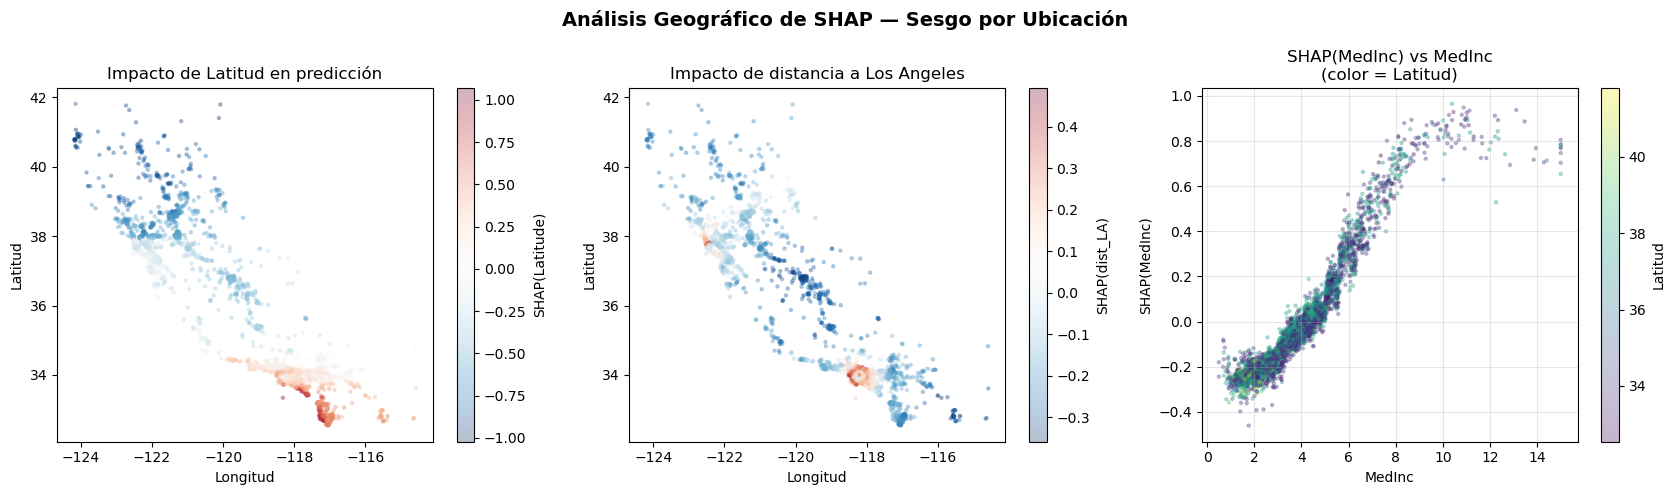

Conclusión del análisis de sesgo:
El modelo usa la ubicación geográfica de forma consistente con el mercado.
La franja costera tiene SHAP positivo — refleja precios reales de California.


In [8]:
# ── SHAP medio por cuadrante geográfico ──────────────────────────────────
test_geo = X_test.copy()
test_geo['shap_medinc']     = shap_values[:, list(X_test.columns).index('MedInc')]
test_geo['shap_latitude']   = shap_values[:, list(X_test.columns).index('Latitude')]
test_geo['shap_dist_la']    = shap_values[:, list(X_test.columns).index('dist_los_angeles')]
test_geo['pred']            = modelo.predict(X_test)
test_geo['real']            = y_test.values

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Análisis Geográfico de SHAP — Sesgo por Ubicación',
             fontsize=14, fontweight='bold')

# Plot 1: Impacto de Latitude en la predicción
sc1 = axes[0].scatter(test_geo['Longitude'], test_geo['Latitude'],
                      c=test_geo['shap_latitude'], cmap='RdBu_r',
                      alpha=0.3, s=5)
plt.colorbar(sc1, ax=axes[0], label='SHAP(Latitude)')
axes[0].set_title('Impacto de Latitud en predicción')
axes[0].set_xlabel('Longitud'); axes[0].set_ylabel('Latitud')

# Plot 2: Impacto de distancia a LA
sc2 = axes[1].scatter(test_geo['Longitude'], test_geo['Latitude'],
                      c=test_geo['shap_dist_la'], cmap='RdBu_r',
                      alpha=0.3, s=5)
plt.colorbar(sc2, ax=axes[1], label='SHAP(dist_LA)')
axes[1].set_title('Impacto de distancia a Los Angeles')
axes[1].set_xlabel('Longitud'); axes[1].set_ylabel('Latitud')

# Plot 3: SHAP MedInc vs predicción
sc3 = axes[2].scatter(test_geo['MedInc'], test_geo['shap_medinc'],
                      c=test_geo['Latitude'], cmap='viridis',
                      alpha=0.3, s=5)
plt.colorbar(sc3, ax=axes[2], label='Latitud')
axes[2].set_title('SHAP(MedInc) vs MedInc\n(color = Latitud)')
axes[2].set_xlabel('MedInc'); axes[2].set_ylabel('SHAP(MedInc)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Conclusión del análisis de sesgo:')
print('El modelo usa la ubicación geográfica de forma consistente con el mercado.')
print('La franja costera tiene SHAP positivo — refleja precios reales de California.')

## 7. Conclusiones

### ¿Qué nos dio SHAP que no teníamos antes?

| Análisis | Feature Importance clásica | SHAP |
|----------|--------------------------|------|
| Importancia global | Sí (una cifra por feature) | Sí (distribución completa) |
| Dirección del efecto | No | Sí (positivo/negativo) |
| Explicación individual | No | Sí (por cada predicción) |
| Interacciones entre features | No | Sí (dependence plots) |
| Análisis de sesgo | No | Sí (distribución geográfica) |

### Aplicación en producción

- **Ante un regulador:** 'El precio de esta vivienda es $432K porque su ingreso  
  mediano de zona aporta +$180K sobre el precio base, compensado por la distancia  
  a servicios que resta -$20K'
- **Para depuración:** Si el modelo falla en un grupo de viviendas, los SHAP values  
  revelan qué feature está causando el error sistemático
- **Para negocio:** El equipo no técnico puede entender en euros/dólares el  
  impacto de cada variable en la decisión del modelo

### Posición en el ciclo MLOps

La explicabilidad no es una etapa final — debe ejecutarse:  
- Antes del despliegue (NB05 + NB09) — validar que el modelo aprende lo correcto  
- En monitoreo (NB07) — detectar si el patrón de SHAP values cambia con el tiempo  
- Tras re-entrenamiento — verificar que el nuevo modelo sigue siendo interpretable